In [ ]:
import os
import socket
import ssl
from concurrent.futures import ThreadPoolExecutor
from urllib.parse import urlparse
import ipaddress


import httpx
from bs4 import BeautifulSoup

from langchain.tools import tool

COMMON_PORTS = {
    21: "ftp", 22: "ssh", 23: "telnet", 25: "smtp", 53: "dns",
    80: "http", 110: "pop3", 143: "imap", 443: "https", 445: "smb",
    3306: "mysql", 3389: "rdp", 5432: "postgres", 6379: "redis",
    8080: "http-alt", 8443: "https-alt", 27017: "mongodb"}


def _host_of(target: str) -> str:
    """Extract a bare host from a URL, host:port, or bare host/IP."""
    parsed = urlparse(target)
    if parsed.scheme and parsed.hostname:
        return parsed.hostname
    return target.split(":")[0].strip()


@tool
def classify_input(raw_input: str) -> dict:
        """Classify a raw target string by shape (url / ip / ip:port / filesystem
        path / git url) WITHOUT any network access. Cheap, safe first step."""



        #CASE 1: normal file path on disk, with checks if its a gitrepo

        if os.path.exists(raw_input):
            return {
                "shape": "filesystem_path",
                "is_git_repo": os.path.isdir(os.path.join(raw_input, ".git")),
            }

        #CASE 2 : git url
        if raw_input.endswith(".git") or raw_input.startswith("git@"):
            return {"shape": "git_url"}

        #CASE 3: URL
        parsed = urlparse(raw_input)
        # returns ParseResult(scheme='https', netloc='example.com:8443', path='/admin', params='', query='q=1', fragment='top')

        if parsed.scheme in ("http", "https"):
            out= {"shape": "url", "host": parsed.hostname, "path": parsed.path}
           
            try:
                ip = ipaddress.ip_address(socket.gethostbyname(parsed.hostname))
                out["is_private"] = ip.is_private
                out["is_loopback"] = ip.is_loopback
            except (ValueError, OSError, TypeError):
                pass


            return out


        #CASE: IP IPV-4 case only

        host = raw_input.split(":")[0]
        try:
            import ipaddress
            ip = ipaddress.ip_address(host)
            return {
                "shape": "ip",
                "is_private": ip.is_private,
                "is_loopback": ip.is_loopback,
            }
        except ValueError:
            return {"shape": "hostname_or_unknown"}

@tool
def deep_port_scan(host: str) -> dict:
        """Scan the common-port set on a host via TCP connect and report which
        are open, with the well-known service name. Read-only. Allowlisted hosts
        only. (Swap in nmap -sV here if you need product/version banners.)"""

        # open (somoneone is listening and accepts the connection), close(instant reply with 'go away'), filtered (no reply at all)
        h = _host_of(host)

        def check(port: int) -> int | None:
            #socket establishes TCP connection
            s = socket.socket()
            s.settimeout(1.0)
            try:
                return port if s.connect_ex((h, port)) == 0 else None
            except OSError:
                return None
            finally:
                s.close()

        with ThreadPoolExecutor(max_workers=12) as ex:
            #map here returns iterator
            found = [p for p in ex.map(check, COMMON_PORTS) if p]
        return {"host": h, "open_ports": {p: COMMON_PORTS[p] for p in found}}

    # --- 3. TLS / certificate inspection ----------------------------------
@tool
def tls_inspect(host: str, port: int = 443) -> dict:
        """Inspect the TLS certificate: issuer, subject, SANs, expiry, TLS
        version. Strong signal for connectivity (public CA -> internet_facing;
        self-signed/localhost -> internal)."""
  
        h = _host_of(host)
        try:
            #ssl.SSLObject
            ctx = ssl.create_default_context()
            with socket.create_connection((h, port), timeout=5) as sock:
                #takes an exisiting standard network socket and upgrades to TLS socket
                with ctx.wrap_socket(sock, server_hostname=h) as ss:
                    cert = ss.getpeercert()
                    return {
                        "issuer": dict(x[0] for x in cert.get("issuer", [])),
                        "subject": dict(x[0] for x in cert.get("subject", [])),
                        "san": [v for _, v in cert.get("subjectAltName", [])],
                        "not_after": cert.get("notAfter"),
                        "tls_version": ss.version(),
                    }
        except Exception as e:  # noqa: BLE001 - report, don't crash the loop
            return {"error": f"{type(e).__name__}: {e}"}

    # --- 4. deep HTTP probe (signals, not content) ------------------------
@tool
def deep_http_probe(url: str) -> dict:
        """GET a URL and extract SIGNALS: status, server/powered-by headers,
        which security headers are present, page title, form actions, input
        *types*, cookie *names*, and a has_password_field boolean. Never returns
        raw field values or page bodies. Read-only, allowlisted hosts only."""

        try:
            r = httpx.get(url, timeout=8.0, follow_redirects=True)
            soup = BeautifulSoup(r.text, "html.parser")
            forms = [
                {
                    "action": f.get("action"),
                    "input_types": [i.get("type") or "text" for i in f.find_all("input")],
                }
                for f in soup.find_all("form")
            ]
            sec = [
                hh for hh in (
                    "strict-transport-security",
                    "content-security-policy",
                    "x-frame-options",
                ) if hh in r.headers
            ]
            return {
                "final_url": str(r.url),
                "status": r.status_code,
                "server": r.headers.get("server"),
                "powered_by": r.headers.get("x-powered-by"),
                "content_type": r.headers.get("content-type"),
                "security_headers_present": sec,
                "title": (soup.title.string or "").strip() if soup.title else None,
                "cookie_names": list(r.cookies.keys()),
                "forms": forms,
                "has_password_field": any(
                    "password" in f["input_types"] for f in forms
                ),
            }
        except Exception as e:  # noqa: BLE001
            return {"error": f"{type(e).__name__}: {e}"}

    # --- 5. codebase inventory (inventory only; secrets are Layer 3) ------
@tool
def codebase_inventory(path: str) -> dict:
        """Inventory a local codebase: top languages by extension, dependency
        manifests, git presence. Read-only. Does NOT grep for secrets or vulns
        (that stays in the Code Analysis Agent)."""
        if not os.path.isdir(path):
            return {"error": f"not a directory: {path}"}
        manifests_of_interest = {
       
            "requirements.txt" , #py
            "pyproject.toml", #py
             "package.json",#js
              "pom.xml",#java
               "go.mod", #go
            "Gemfile", #ruby
             "Cargo.toml", #rust
              "composer.json"         #php
              }
        exts: dict[str, int] = {}
        #It's a language/dependency detector 
        # the manifest files are proxies for "what does this project depend on and what stack is it built with.
        manifests: list[str] = []
        for root, _dirs, files in os.walk(path):
            if ".git" in root:
                continue
            for f in files:
                #get the extension eg.py or md
                ext = os.path.splitext(f)[1]
                if ext:
                    exts[ext] = exts.get(ext, 0) + 1
                if f in manifests_of_interest:
                    manifests.append(os.path.join(root, f))
        #sort by decending
        top = dict(sorted(exts.items(), key=lambda kv: -kv[1])[:8])
        return {
            "languages_by_ext": top,
            "manifests": manifests,
            "is_git": os.path.isdir(os.path.join(path, ".git")),
        }

tools= [
        classify_input,
        deep_port_scan,
        tls_inspect,
        deep_http_probe,
        codebase_inventory,
    ]



In [5]:
from langchain_openai import ChatOpenAI
api='sk-DST7tpm4cQeyFnqd00D8bIKWPdOyhpLnKAcHM3UGUwuc0xrs'

model = ChatOpenAI(
    api_key=api, base_url="https://apihub.agnes-ai.com/v1",model='agnes-2.0-flash'
)

In [6]:
from langgraph.graph import add_messages
from langchain_core.messages import BaseMessage
from typing import Annotated

from typing import List, Literal, Optional, TypedDict
 
from pydantic import BaseModel, Field
 
# --- Enumerations (your originals) -----------------------------------------
 
TargetType = Literal[
    "web_app", "api", "embedded_system", "codebase", "network_service"
]
 
Connectivity = Literal[
    "internet_facing", "internal", "offline", "containerised"
]
 
# HIPAA: Health/medical data handling
# PDPA:  General personal data handling
# PCI_DSS: Payment card / financial data handling
RegulatoryFlag = Literal["HIPAA", "PDPA", "PCI_DSS"]
 
# standard: Simple Python process, no isolation
# sandbox:  Agents run inside an isolated Docker container
# privacy:  Standard process, but findings get PII redaction + LOCAL LLM
# air_gap:  No internet access at all
ExecutionMode = Literal["standard", "privacy", "air_gap", "sandbox"]
 
 
# --- Profiler output contract ----------------------------------------------
 
class DataSensitivity(BaseModel):
    """Data sensitivity assessment for a target."""
 
    handles_pii: bool = Field(
        description="Target stores or processes personally identifiable information."
    )
    handles_credentials: bool = Field(
        description="Target stores or processes authentication credentials."
    )
    handles_financial_data: bool = Field(
        description="Target stores or processes financial/payment data."
    )
    handles_health_records: bool = Field(
        description="Target stores or processes health/medical records."
    )
 
 
class TargetProfile(BaseModel):
    """Structured output of the Profiler Agent.
 
    One instance is produced per scan target and consumed by the mode-selection
    step to choose an ExecutionMode. Because the Recon Agent has been folded
    into the Profiler, this profile also carries the deep-recon evidence trail
    in `notes`.
    """
 
    target_id: str = Field(description="Stable identifier for this target within a run.")
    raw_input: str = Field(description="Original input supplied by the user (URL, IP, path, etc).")
    target_type: TargetType = Field(description="Classification of the target system type.")
    connectivity: Connectivity = Field(description="Network reachability posture of the target.")
    
    #--------------------------------user provide---------------
    data_sensitivity: DataSensitivity = Field(description="Structured data sensitivity assessment.")
    regulatory_flags: List[RegulatoryFlag] = Field(
        default_factory=list,
        description="Regulatory regimes the target appears to fall under, if any.",
    )
    #--------------------------------------------------------------
    recommended_mode: ExecutionMode = Field(
        description="Execution mode the Profiler recommends the Orchestrator activate."
    )
    confidence: float = Field(
        ge=0.0,
        le=1.0,
        description="Profiler's confidence in this classification (0.0-1.0). "
        "Low-confidence profiles push mode selection toward more isolation.",
    )
    notes: Optional[str] = Field(
        default=None,
        description="Free-text reasoning trail from the Profiler, including a "
        "summary of the deep-recon evidence gathered.",
    )
 
 
# --- LangGraph state --------------------------------------------------------
 
class ProfilerState(TypedDict, total=False):
    raw_input: str
    declared_sensitivity: DataSensitivity
    declared_regulatory: List[RegulatoryFlag]
    target_id: str
    #for LLM
    messages: Annotated[list[BaseMessage], add_messages]
    profile: Optional[TargetProfile]

    #retry 
    retry : int





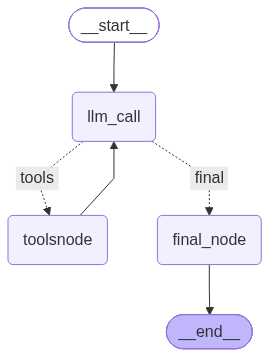

In [ ]:
from langchain_core.messages import ToolMessage
from langsmith._openapi_client.types import run_select_field
from langgraph.prebuilt import ToolCallTransformer
from langchain_core.messages import SystemMessage, BaseMessage
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage

graph=StateGraph(ProfilerState)

model_tools=model.bind_tools(tools)






def _select_execution_mode(p: TargetProfile) -> ExecutionMode:
    ds= p.data_sensitivity


    #confidentiality case
    health= ds.handles_health_records or 'HIPAA' in p.regulatory_flags
    other_regulated = (
        ds.handles_pii or ds.handles_financial_data
        or "PDPA" in p.regulatory_flags or "PCI_DSS" in p.regulatory_flags
    )

    #containment case
    hostile_risk= (
        p.target_type == "codebase"        # about to walk/parse untrusted files
        or ds.handles_credentials          # compromise here is high-value
        or p.confidence < 0.6              # unknown target = unknown risk
    )

    #feabsibile : air_gap cannot reach internet facing target
    reachable_offline = p.connectivity in ("offline", "internal", "containerised")

    if health and reachable_offline:
        return 'air_gap'
    if health or other_regulated:
        return 'privacy'
    if hostile_risk:
        return 'sandbox'
    return 'standard'
    








def llm_call(state: ProfilerState):
    messages = list(state.get("messages") or [])
    new: list[BaseMessage] = []

    if not messages:
        system_prompt = """You are a security profiler. Assess the target's type,
        connectivity, and data sensitivity, and recommend the most conservative safe
        execution mode. Use the available tools to investigate before concluding.
        When uncertain, lower your confidence and prefer isolation."""

        user_prompt = f"""Target input: {state['raw_input']}
        User-declared sensitivity: {state['declared_sensitivity']}
        User-declared regulatory flags: {state['declared_regulatory']}
        Target id: {state['target_id']}"""

        new = [SystemMessage(system_prompt), HumanMessage(user_prompt)]
        messages = new

    response = model_tools.invoke(messages)
    



    return {"messages": [*new, response], "retry": state.get("retry", 0) + 1}


def finalize(state: ProfilerState):

    messages = [
        *state["messages"],
        HumanMessage("Using the evidence above, produce the TargetProfile."),
    ]
    profile = model.with_structured_output(TargetProfile).invoke(messages)

    declared_sensitivity = state["declared_sensitivity"]
    declared_regulatory = state.get("declared_regulatory", [])
    
    profile = TargetProfile(
        **{
            **profile.model_dump(),
            "target_id": state["target_id"],
            "raw_input": state["raw_input"],
            "data_sensitivity": declared_sensitivity,
            "regulatory_flags": declared_regulatory,
        }
    )
    tools_msgs = [m for m in state['messages'] if isinstance(m,ToolMessage)]
   # a target counts as OBSERVED if any tool actually made contact with it.
    # ratio-of-errors doesn't work: deep_port_scan can never fail (it reports
    # {} open ports for a host that doesn't resolve), so it dilutes the ratio,
    # while tls_inspect against a plain-HTTP port errors on a target that was
    # seen perfectly well.
    SEEN = ('"status"',                    # deep_http_probe got a response
            '"tls_version"',               # tls_inspect completed a handshake
            '"languages_by_ext"',          # codebase_inventory walked the tree
            '"shape": "filesystem_path"')  # the path exists on disk
    reached = any(k in str(m.content) for m in tools_msgs for k in SEEN)

    if tools_msgs and not reached:
        profile.confidence = min(profile.confidence, 0.4)



    profile.recommended_mode = _select_execution_mode(profile)
    return {'profile': profile}

def should_route(state: ProfilerState):
    lm=state['messages'][-1]

    if state['retry']==10:
        return 'final'
    if getattr(lm, "tool_calls", None):
        return "tools"
    return 'final'



graph.add_node("llm_call", llm_call)
graph.add_node('toolsnode',ToolNode(tools))
graph.add_node('final_node',finalize)
graph.add_edge(START,'llm_call')
graph.add_conditional_edges('llm_call',should_route,{

    'tools':'toolsnode', 'final':'final_node'
})

graph.add_edge('toolsnode','llm_call')
graph.add_edge('final_node',END)

app=graph.compile()
app

In [8]:
q = {
    'raw_input': 'https://docs.langchain.com/oss/python/langgraph/quickstart',
    'declared_sensitivity': {
        'handles_pii': False,
        'handles_credentials': False,
        'handles_financial_data': False,
        'handles_health_records': False,
    },
    'declared_regulatory': ['PDPA'],
    'target_id': '1',
    'retry': 0
}
app.invoke(q)

{'raw_input': 'https://docs.langchain.com/oss/python/langgraph/quickstart',
 'declared_sensitivity': {'handles_pii': False,
  'handles_credentials': False,
  'handles_financial_data': False,
  'handles_health_records': False},
 'declared_regulatory': ['PDPA'],
 'target_id': '1',
 'messages': [SystemMessage(content="You are a security profiler. Assess the target's type,\n        connectivity, and data sensitivity, and recommend the most conservative safe\n        execution mode. Use the available tools to investigate before concluding.\n        When uncertain, lower your confidence and prefer isolation.", additional_kwargs={}, response_metadata={}, id='70c64de7-4b84-4630-b1c4-9061f77b4d9a'),
  HumanMessage(content="Target input: https://docs.langchain.com/oss/python/langgraph/quickstart\n        User-declared sensitivity: {'handles_pii': False, 'handles_credentials': False, 'handles_financial_data': False, 'handles_health_records': False}\n        User-declared regulatory flags: ['PDPA'

In [9]:
stream = app.stream_events(q, version="v3", transformers=[ToolCallTransformer])

for kind, item in stream.interleave("messages", "tool_calls"):
    if kind == "messages":
        for token in item.text:
            print(token, end="", flush=True)
    elif kind == "tool_calls":
        print(f"\nTool call: {item.tool_name}({item.input})")
        for delta in item.output_deltas:
            print(delta, end="", flush=True)
        print(f"\nTool result: {item.output}")

c:\Users\User\OneDrive - Nanyang Technological University\MLDAProject\.venv\Lib\site-packages\langgraph\pregel\main.py:3708: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return self._pregel_stream_v3(
c:\Users\User\OneDrive - Nanyang Technological University\MLDAProject\.venv\Lib\site-packages\langgraph\pregel\main.py:3558: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return GraphRunStream(graph_iter, mux)






You are a security profiler. Assess the target's type,
        connectivity, and data sensitivity, and recommend the most conservative safe
        execution mode. Use the available tools to investigate before concluding.
        When uncertain, lower your confidence and prefer isolation.Target input: https://docs.langchain.com/oss/python/langgraph/quickstart
        User-declared sensitivity: {'handles_pii': False, 'handles_credentials': False, 'handles_financial_data': False, 'handles_health_records': False}
        User-declared regulatory flags: ['PDPA']
        Target id: 1
Tool call: classify_input({'raw_input': 'https://docs.langchain.com/oss/python/langgraph/quickstart'})

Tool result: content='{"shape": "url", "host": "docs.langchain.com", "path": "/oss/python/langgraph/quickstart"}' name='classify_input' tool_call_id='call_a73226cecea5481788aebe3e'

Tool call: deep_http_probe({'url': 'https://docs.langchain.com/oss/python/langgraph/quickstart'})

Tool result: content='{"f

c:\Users\User\OneDrive - Nanyang Technological University\MLDAProject\.venv\Lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=TargetProfile(target_id='...xecution mode applied.'), input_type=TargetProfile])
  return self.__pydantic_serializer__.to_python(


In [10]:
stream.output['profile']

TargetProfile(target_id='1', raw_input='https://docs.langchain.com/oss/python/langgraph/quickstart', target_type='web_app', connectivity='internet_facing', data_sensitivity=DataSensitivity(handles_pii=False, handles_credentials=False, handles_financial_data=False, handles_health_records=False), regulatory_flags=['PDPA'], recommended_mode='privacy', confidence=0.82, notes='Public open-source documentation site. TLS 1.3, Cloudflare protection, HSTS/CSP headers present. PDPA flag set by user despite no detected PII; conservative execution mode applied.')

In [11]:

stream = app.stream_events(q, version="v3", transformers=[ToolCallTransformer])
for message in stream.messages:
    text = str(message.text)
    usage = message.output.usage_metadata

    print(text)
    print(usage)






{'input_tokens': 1166, 'output_tokens': 160, 'total_tokens': 1326, 'output_token_details': {'reasoning': 33}}
You are a security profiler. Assess the target's type,
        connectivity, and data sensitivity, and recommend the most conservative safe
        execution mode. Use the available tools to investigate before concluding.
        When uncertain, lower your confidence and prefer isolation.
None
Target input: https://docs.langchain.com/oss/python/langgraph/quickstart
        User-declared sensitivity: {'handles_pii': False, 'handles_credentials': False, 'handles_financial_data': False, 'handles_health_records': False}
        User-declared regulatory flags: ['PDPA']
        Target id: 1
None


## Security Profiler Assessment — Target 1

### Classification
| Field | Value |
|-------|-------|
| **Shape** | URL |
| **Host** | `docs.langchain.com` |
| **Path** | `/oss/python/langgraph/quickstart` |

### Connectivity & Infrastructure
| Signal | Detail |
|--------|--------|
| **HT

c:\Users\User\OneDrive - Nanyang Technological University\MLDAProject\.venv\Lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=TargetProfile(target_id='... isolation for safety.'), input_type=TargetProfile])
  return self.__pydantic_serializer__.to_python(
